In [2]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import pandas as pd
import scanpy as sc
import torch
import matplotlib.pyplot as plt
import matplotlib

from TrajectoryNet import dataset, eval_utils
from TrajectoryNet.parse import parser
from TrajectoryNet.lib.growth_net import GrowthNet
from TrajectoryNet.lib.viz_scrna import trajectory_to_video, save_vectors

from TrajectoryNet.train_misc import (
    set_cnf_options,
    add_spectral_norm,
    create_regularization_fns,
    build_model_tabular,
)

/ssd/users/Wergillius/miniforge3/envs/torchcfm/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/ssd/users/Wergillius/miniforge3/envs/torchcfm/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/ssd/users/Wergillius/miniforge3/envs/torchcfm/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/ssd/users/Wergillius/miniforge3/envs/torchcfm/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_mtx from `anndata` is deprecated. Import anndata.io.read_mtx instead.
  warnings.warn(msg, FutureWarning)
/ssd/users/Wergillius/miniforge3/envs/torchcfm/lib/python3

[KeOps] Warning : Cuda libraries were not detected on the system or could not be loaded ; using cpu only mode


In [3]:
os.chdir("/ssd/users/Wergillius/Project/PINN_dynamics")

In [4]:
adata = sc.read_h5ad("data/klein_subset.h5ad")
Fate_bias = pd.read_csv("data/Weinreb/F_obs.csv", index_col=0)
Fate_bias.index = Fate_bias.index.astype(str)

cellstate_key = "DM_EigenVectors_multiscaled"

overlapped_cbs = np.intersect1d(Fate_bias.index, adata.obs_names)
overlapped_cb_index = [np.where(adata.obs_names == cb)[0] for cb in overlapped_cbs]

In [5]:
test_clones = ['Clone_3869' , 'Clone_2673' , 'Clone_2831']
cbs = [adata.obs.query("`timepoint_tx_days` == @t & `clones` in @test_clones").index.to_list()
            for t in adata.uns['pop']['t']]
W2_cb_indexs = [[np.where(adata.obs_names == cb)[0] for cb in cb_t] for cb_t in cbs]

In [6]:
DM_whiten_args =[
    "--dataset", "data/klein_for_TJN.npz",
    "--embedding_name", "DM",
    "--max_dim", "5",
    "--niters", "3000",
    "--save", "logs/TrajectoryNet/Weinreb_DM_whiten",
    "--growth_path", "logs/TrajectoryNet/Weinreb_DM_whiten/klein_TJN_growth_model.pt",
    "--whiten",
    "--use_growth"
            ]
DM_args =[
    "--dataset", "data/klein_for_TJN.npz",
    "--embedding_name", "DM",
    "--max_dim", "5",
    "--niters", "3000",
    "--save", "logs/TrajectoryNet/DM_multiscaled_with_growth",
    "--growth_path", "logs/TrajectoryNet/klein_TJN_growth_model.pt",
    "--use_growth"
            ]
            

In [7]:
PCA_args =[
    "--dataset", "data/klein_PCA_TJN.npz",
    "--embedding_name", "DM",
    "--max_dim", "50",
    "--niters", "3000",
    "--save", "logs/TrajectoryNet/Weinreb_PCA",
            ]

PCA_whiten_args =[
    "--dataset", "data/klein_PCA_TJN.npz",
    "--embedding_name", "DM",
    "--max_dim", "50",
    "--niters", "3000",
    "--save", "logs/TrajectoryNet/Weinreb_PCA_whiten",
    "--whiten",
            ]

# load config

In [8]:
args = parser.parse_args(
    DM_args
)

In [9]:
data = dataset.SCData.factory(args.dataset, args)

timepoints = data.get_unique_times()
# Use maximum timepoint to establish integration_times
int_tps = (np.arange(max(timepoints) + 1) + 1.0) * args.time_scale
print(timepoints)
print(int_tps)

No velocity found for embedding DM skipping velocity
[2 4 6]
[0.5 1.  1.5 2.  2.5 3.  3.5]


In [10]:
regularization_fns, regularization_coeffs = create_regularization_fns(args)

# load CNF model

In [11]:
device = 'cuda:0'

In [12]:
ckpt = torch.load(f"{args.save}/checkpt-3000.pth")

/tmp/ipykernel_729726/3776158467.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(f"{args.save}/checkpt-3000.pth")


In [13]:
model = build_model_tabular(args, data.get_shape()[0], regularization_fns).to(device)
# growth_model = torch.load(args.growth_path, map_location=device)
model.load_state_dict(ckpt['state_dict'])

<All keys matched successfully>

In [14]:
cnf_net = model.chain[0]

In [45]:
cnf_net

CNF(
  (odefunc): RegularizedODEfunc(
    (odefunc): ODEfunc(
      (diffeq): ODEnet(
        (layers): ModuleList(
          (0): ConcatSquashLinear(
            (_layer): Linear(in_features=5, out_features=64, bias=True)
            (_hyper_bias): Linear(in_features=1, out_features=64, bias=False)
            (_hyper_gate): Linear(in_features=1, out_features=64, bias=True)
          )
          (1-2): 2 x ConcatSquashLinear(
            (_layer): Linear(in_features=64, out_features=64, bias=True)
            (_hyper_bias): Linear(in_features=1, out_features=64, bias=False)
            (_hyper_gate): Linear(in_features=1, out_features=64, bias=True)
          )
          (3): ConcatSquashLinear(
            (_layer): Linear(in_features=64, out_features=5, bias=True)
            (_hyper_bias): Linear(in_features=1, out_features=5, bias=False)
            (_hyper_gate): Linear(in_features=1, out_features=5, bias=True)
          )
        )
        (activation_fns): ModuleList(
         

# simualte for Wassterin 

In [15]:
X_DM=adata.obsm[cellstate_key]

# starting cells at Day4
X_test_w = data.data[W2_cb_indexs[1]][:,0,:]

# starting true cells at Day6
X_true = data.data[W2_cb_indexs[2]][:,0,:]


X_testw_ts = torch.tensor(X_test_w).float().to(device)

In [16]:
X_testw_ts.shape

torch.Size([65, 5])

In [17]:
from torchcfm.optimal_transport import wasserstein

In [51]:
# integration_times = torch.tensor([2.0, 3.5]).float()
# integration_times = torch.tensor([0.5, 1.0]).float() 

# z, delta_logp = cnf_net(X_testw_ts, zero, integration_times=integration_times, reverse=True)

with torch.no_grad():

    zs = [X_testw_ts] 
    # zs = [torch.tensor(X_last).to(device).float()]
    deltas = []
    int_tps = np.linspace(0.3, 0.7, 101)

    zero = torch.zeros((zs[0].shape[0],1)).type(torch.float32).to(device)

    for i, itp in enumerate(int_tps[1:]):
    # for i, itp in enumerate(int_tps[::-1][:-1]):
        # tp counts down from last
        timescale = int_tps[1] - int_tps[0]
        integration_times = torch.tensor([itp - timescale, itp])
        # integration_times = torch.tensor([np.linspace(itp - args.time_scale, itp, ntimes)])
        integration_times = integration_times.type(torch.float32).to(device)

        # transform to previous timepoint
        z, delta_logp = cnf_net(zs[-1], zero, integration_times=integration_times, reverse=False)
        zs.append(z)
        deltas.append(delta_logp)

        if i%10 == 0:
            print(integration_times)

    zs = torch.stack(zs, 0).cpu()#.numpy()

W = [wasserstein(zs[i], torch.tensor(X_true), power=2, method='exact') for i in range(101)]
np.min(W), np.argmin(W)

tensor([0.3000, 0.3040], device='cuda:0')
tensor([0.3400, 0.3440], device='cuda:0')
tensor([0.3800, 0.3840], device='cuda:0')
tensor([0.4200, 0.4240], device='cuda:0')
tensor([0.4600, 0.4640], device='cuda:0')
tensor([0.5000, 0.5040], device='cuda:0')
tensor([0.5400, 0.5440], device='cuda:0')
tensor([0.5800, 0.5840], device='cuda:0')
tensor([0.6200, 0.6240], device='cuda:0')
tensor([0.6600, 0.6640], device='cuda:0')


(3.1446056333861345, 86)

In [52]:
len(zs)

101

In [53]:
args.save

'logs/TrajectoryNet/DM_multiscaled_with_growth'

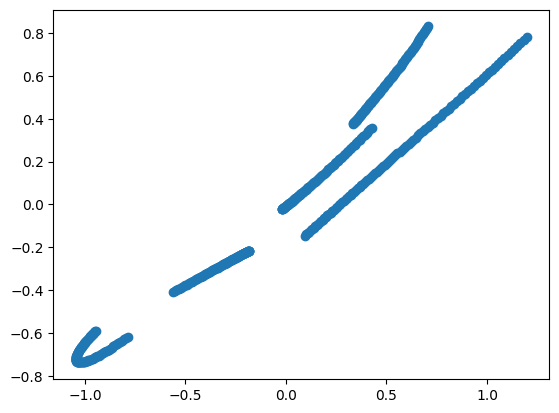

In [54]:
# %matplotlib inline
which_dim=(0,1)
# zs = zs.numpy()

fig = plt.figure()
plt.scatter(zs[:,0], zs[:,1])
fig

In [55]:
wasserstein(zs[-1], torch.tensor(X_true), power=2, method='exact')

print("W2: \t", wasserstein(zs[-1], torch.tensor(X_true), power=2, method='exact'))
print("W2 skh reg=0.01: \t", wasserstein(zs[-1], torch.tensor(X_true), power=2, method='sinkhorn', reg=0.05))
print("W2 skh reg=0.05: \t", wasserstein(zs[-1], torch.tensor(X_true), power=2, method='sinkhorn', reg=0.5))
print("W2 skh reg=1: \t", wasserstein(zs[-1], torch.tensor(X_true), power=2, method='sinkhorn', reg=5))

W2: 	 3.163165066227144
W2 skh reg=0.01: 	 1.0808731754703298e-06
W2 skh reg=0.05: 	 3.1929474793997983
W2 skh reg=1: 	 3.381883077009947


/ssd/users/Wergillius/miniforge3/envs/torchcfm/lib/python3.10/site-packages/ot/bregman/_sinkhorn.py:498: RuntimeWarning: divide by zero encountered in divide
  v = b / KtransposeU
/ssd/users/Wergillius/miniforge3/envs/torchcfm/lib/python3.10/site-packages/ot/bregman/_sinkhorn.py:506: UserWarning: Warning: numerical errors at iteration 0
  warnings.warn('Warning: numerical errors at iteration %d' % ii)


In [57]:
np.save(f"{args.save}/wasstein_trajectories_2d0-3d5.npy", zs.numpy()[:86])


# simulate for fate bias

compare the adata raw DM and the whiten DM

In [287]:
X = data.data
print(X.std(axis=0))
print(X.min(axis=0))
print(X.max(axis=0))

[1.6709534  1.2887695  0.8867384  0.72486633 0.64564335]
[-4.3566866 -1.9703084 -7.9128222 -8.285539  -1.2938874]
[3.4795609 2.784506  1.9373026 0.6689912 4.7552433]


In [288]:
X_DM=adata.obsm[cellstate_key]
print(X_DM.std(axis=0))
print(X_DM.min(axis=0))
print(X_DM.max(axis=0))

[1.6709534  1.2887695  0.8867384  0.72486633 0.64564335]
[-4.3566866 -1.9703084 -7.9128222 -8.285539  -1.2938874]
[3.4795609 2.784506  1.9373026 0.6689912 4.7552433]


In [289]:
X_test_ay = data.data[overlapped_cb_index]
X_test_ay = X_test_ay[:,0,:]

X_test = torch.tensor(X_test_ay).float().to(device)

In [290]:
X_last = data.get_data()[data.get_times() == 6]

In [291]:
int_tps = np.linspace(0.5, 3.0, 101)

In [292]:
integration_times = torch.tensor([1.0, 3.5]).float()
z, delta_logp = cnf_net(X_test, zero, integration_times=integration_times, reverse=True)

with torch.no_grad():

    zs = [X_test] 
    # zs = [torch.tensor(X_last).to(device).float()]
    deltas = []
    int_tps = np.linspace(0.5, 3.0, 101)

    zero = torch.zeros((zs[0].shape[0],1)).type(torch.float32).to(device)

    for i, itp in enumerate(int_tps[1:]):
    # for i, itp in enumerate(int_tps[::-1][:-1]):
        # tp counts down from last
        timescale = int_tps[1] - int_tps[0]
        integration_times = torch.tensor([itp - timescale, itp])
        # integration_times = torch.tensor([np.linspace(itp - args.time_scale, itp, ntimes)])
        integration_times = integration_times.type(torch.float32).to(device)

        # transform to previous timepoint
        z, delta_logp = cnf_net(zs[-1], zero, integration_times=integration_times, reverse=True)
        zs.append(z)
        deltas.append(delta_logp)

        if i%10 == 0:
            print(integration_times)

    zs = torch.stack(zs, 0).cpu().numpy()

tensor([0.5000, 0.5250], device='cuda:0')
tensor([0.7500, 0.7750], device='cuda:0')
tensor([1.0000, 1.0250], device='cuda:0')
tensor([1.2500, 1.2750], device='cuda:0')
tensor([1.5000, 1.5250], device='cuda:0')
tensor([1.7500, 1.7750], device='cuda:0')
tensor([2.0000, 2.0250], device='cuda:0')
tensor([2.2500, 2.2750], device='cuda:0')
tensor([2.5000, 2.5250], device='cuda:0')
tensor([2.7500, 2.7750], device='cuda:0')


In [293]:
zs.shape

(101, 1989, 5)

In [294]:
from matplotlib import pyplot as plt
%matplotlib inline

In [295]:
zs[-1].shape

(1989, 5)

In [296]:
integration_times.tolist()

[2.9749999046325684, 3.0]

In [297]:
integration_times = torch.tensor([0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5]).float()
z, delta_logp = cnf_net(X_test, zero, integration_times=integration_times, reverse=True)
z = z.detach().cpu().numpy()

In [298]:
z.shape

(7, 1989, 5)

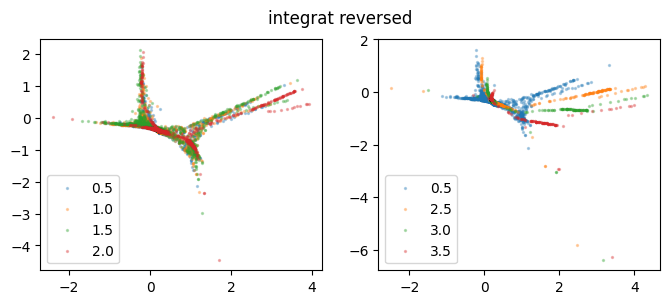

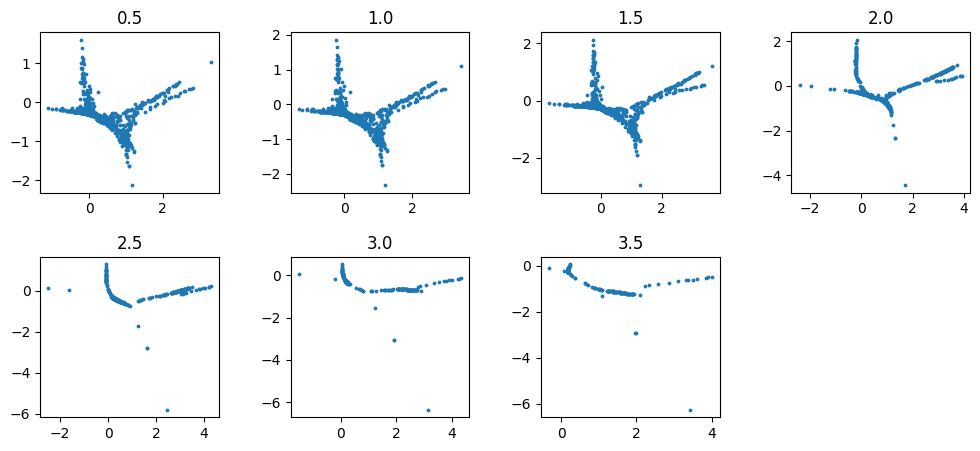

In [299]:
%matplotlib inline
int_time = [0.5, 1.0, 1.5, 2.0, 2.5,3.0, 3.5]
z, delta_logp = cnf_net(X_test, zero,  reverse=True,
                            integration_times=torch.tensor(int_time).float())
z = z.detach().cpu().numpy()

fig, axs = plt.subplots(1,2, figsize=(8,3))

for i in range(4):
    axs[0].scatter(z[i][:,0], z[i][:,2], s=2, alpha=0.3)

axs[1].scatter(z[0][:,0], z[0][:,2], s=2, alpha=0.3)
for i in range(4,7):
    axs[1].scatter(z[i][:,0], z[i][:,2], s=2, alpha=0.3)

axs[0].legend(int_time[:4])
axs[1].legend(int_time[:1]+int_time[4:])
fig.suptitle(f"integrat reversed")
plt.show()


fig, axs = plt.subplots(2, 4, figsize=(12,5), gridspec_kw={"hspace":0.4, "wspace":0.4})
axs = axs.flatten()

for i,t in enumerate(int_time):
    axs[i].scatter(z[i][:,0], z[i][:,2], s=3)
    axs[i].set_title(str(t))

axs[-1].axis("off")
plt.show()

In [300]:
np.save(f"{args.save}/fate_bias_trajectories_0d5-3d5.npy", z)

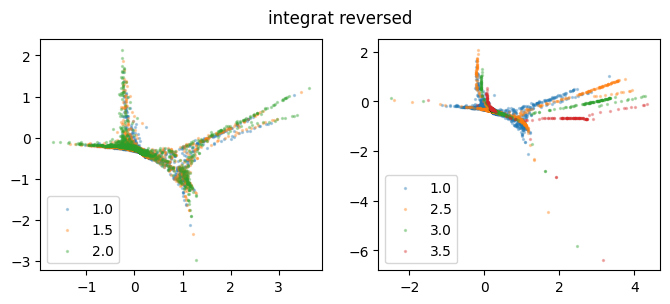

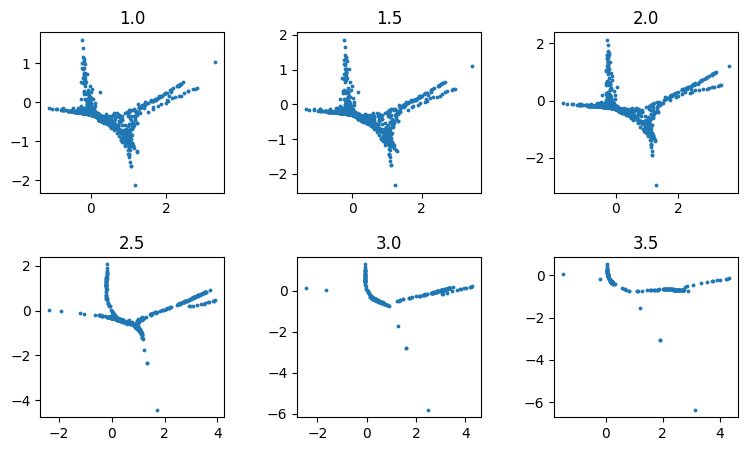

In [301]:
%matplotlib inline
int_time = [1.0, 1.5, 2.0, 2.5,3.0, 3.5]
z, delta_logp = cnf_net(X_test, zero,  reverse=True,
                            integration_times=torch.tensor(int_time).float())
z = z.detach().cpu().numpy()

fig, axs = plt.subplots(1,2, figsize=(8,3))

for i in range(3):
    axs[0].scatter(z[i][:,0], z[i][:,2], s=2, alpha=0.3)

axs[1].scatter(z[0][:,0], z[0][:,2], s=2, alpha=0.3)
for i in range(3,len(int_time)):
    axs[1].scatter(z[i][:,0], z[i][:,2], s=2, alpha=0.3)

axs[0].legend(int_time[:3])
axs[1].legend(int_time[:1]+int_time[3:])
fig.suptitle(f"integrat reversed")
plt.show()

fig, axs = plt.subplots(2, 3, figsize=(9,5),  gridspec_kw={"hspace":0.4, "wspace":0.4})
axs = axs.flatten()

for i,t in enumerate(int_time):
    axs[i].scatter(z[i][:,0], z[i][:,2], s=3)
    axs[i].set_title(str(t))
plt.show()

In [302]:
np.save(f"{args.save}/fate_bias_trajectories_1d0-3d5.npy", z)

# the eval backward trajectories

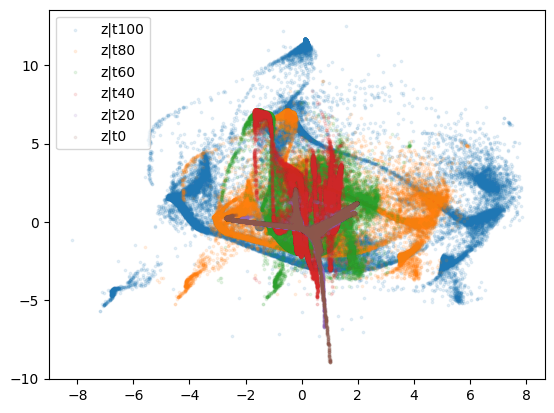

In [192]:
bw_traj = np.load("logs/TrajectoryNet/Weinreb_DM_whiten/backward_trajectories.npy")

%matplotlib inline
plt.scatter(bw_traj[-1][:,0], bw_traj[-1][:,2], s=3, alpha=0.1)
plt.scatter(bw_traj[80][:,0], bw_traj[80][:,2], s=3, alpha=0.1)
plt.scatter(bw_traj[60][:,0], bw_traj[80][:,2], s=3, alpha=0.1)
plt.scatter(bw_traj[40][:,0], bw_traj[80][:,2], s=3, alpha=0.1)
plt.scatter(bw_traj[20][:,0], bw_traj[20][:,2], s=3, alpha=0.1)
plt.scatter(bw_traj[0][:,0], bw_traj[0][:,2], s=3, alpha=0.1)
plt.legend(['z|t100', 'z|t80','z|t60', 'z|t40', 'z|t20', 'z|t0'])
plt.show()

# no growth no whiten

In [113]:
bw_traj = np.load("logs/TrajectoryNet/backward_trajectories.npy")

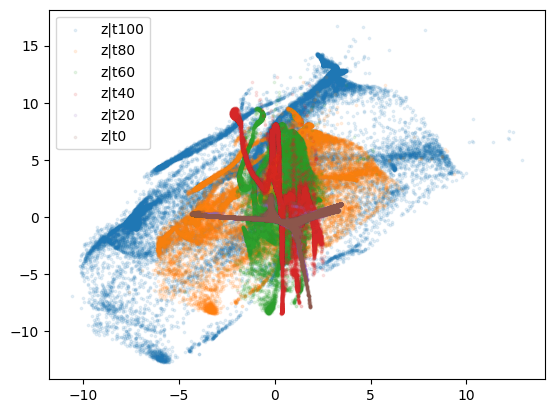

In [130]:
%matplotlib inline
plt.scatter(bw_traj[-1][:,0], bw_traj[-1][:,2], s=3, alpha=0.1)
plt.scatter(bw_traj[80][:,0], bw_traj[80][:,2], s=3, alpha=0.1)
plt.scatter(bw_traj[60][:,0], bw_traj[80][:,2], s=3, alpha=0.1)
plt.scatter(bw_traj[40][:,0], bw_traj[80][:,2], s=3, alpha=0.1)
plt.scatter(bw_traj[20][:,0], bw_traj[20][:,2], s=3, alpha=0.1)
plt.scatter(bw_traj[0][:,0], bw_traj[0][:,2], s=3, alpha=0.1)
plt.legend(['z|t100', 'z|t80','z|t60', 'z|t40', 'z|t20', 'z|t0'])
plt.show()